#Data Preparation

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Import Libraries
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Load Dataset
dataset_path = '/content/drive/MyDrive/Project/dataset/News Dataset.csv'
df = pd.read_csv(dataset_path)



Mounted at /content/drive


#Preprocessing

In [ ]:
#  Inspect Columns
print("Columns in dataset:", df.columns.tolist())
df.head()

# Preprocess Content
# Fill missing content and lowercase
df['content'] = df['content'].fillna('')
df['content'] = df['content'].str.lower()

# Optional: Fill missing title/category if needed
df['title'] = df['title'].fillna('No Title')
if 'category' in df.columns:
    df['category'] = df['category'].fillna('Unknown')




Columns in dataset: ['source', 'author', 'title', 'description', 'url', 'urlToImage', 'publishedAt', 'content', 'category']


#Feature Engineering

In [ ]:
#  Create TF-IDF Matrix
tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform(df['content'])
print("TF-IDF matrix shape:", tfidf_matrix.shape)


TF-IDF matrix shape: (700, 4869)


#Baseline Similarity Models

**Cosine Similarity **

Cosine similarity matrix shape: (700, 700)


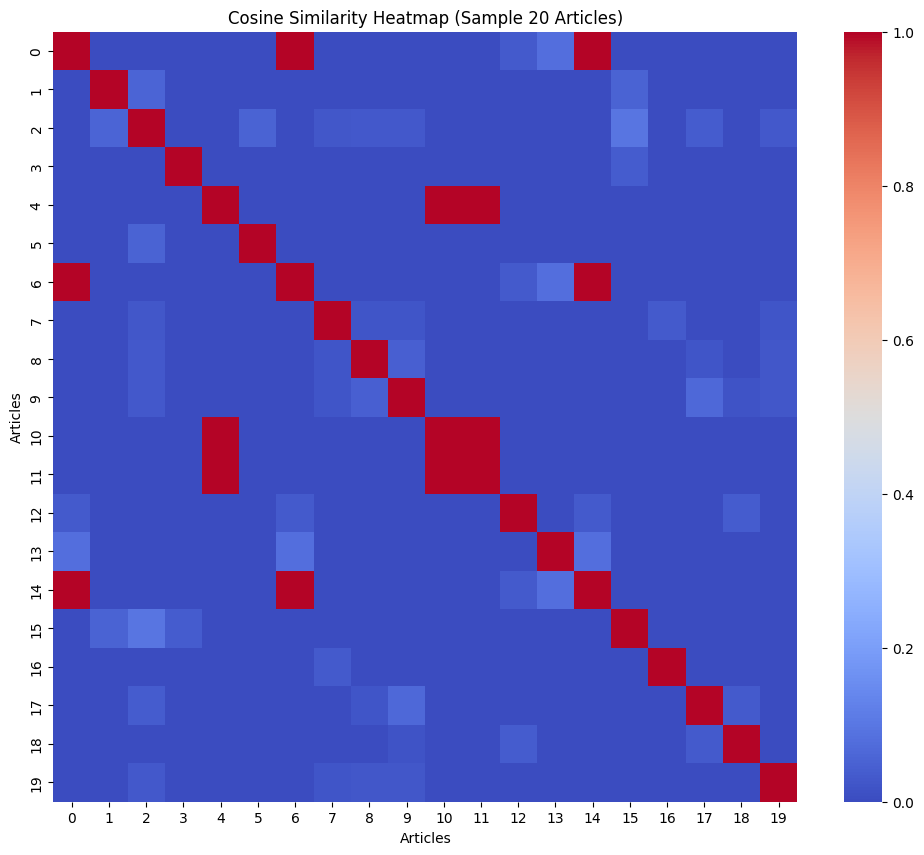

In [ ]:
#  Compute Cosine Similarity
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)
print("Cosine similarity matrix shape:", cosine_sim.shape)

#  Add heatmap visualization here
import seaborn as sns
import matplotlib.pyplot as plt

# Optional: sample first 20 articles to keep it readable
sample_matrix = cosine_sim[:20, :20]

plt.figure(figsize=(12,10))
sns.heatmap(sample_matrix, annot=False, cmap='coolwarm')
plt.title("Cosine Similarity Heatmap (Sample 20 Articles)")
plt.xlabel("Articles")
plt.ylabel("Articles")
plt.show()

# Recommendation Function

In [ ]:

def recommend_with_graph(article_index, top_n=5):
    scores = list(enumerate(cosine_sim[article_index]))
    scores = sorted(scores, key=lambda x: x[1], reverse=True)
    top_articles = scores[1:top_n+1]

    titles = [df.loc[i, 'title'] for i, _ in top_articles]
    sim_scores = [score for _, score in top_articles]

    # Bar chart
    plt.figure(figsize=(10,5))
    sns.barplot(x=sim_scores, y=titles, palette='viridis')
    plt.xlabel("Similarity Score")
    plt.title(f"Top {top_n} Recommendations for: {df.loc[article_index, 'title']}")
    plt.show()

    # Also print text output
    for i, score in top_articles:
        print(f"{df.loc[i, 'title']} — Similarity: {score:.2f}")


/tmp/ipython-input-475/4031343370.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sim_scores, y=titles, palette='viridis')


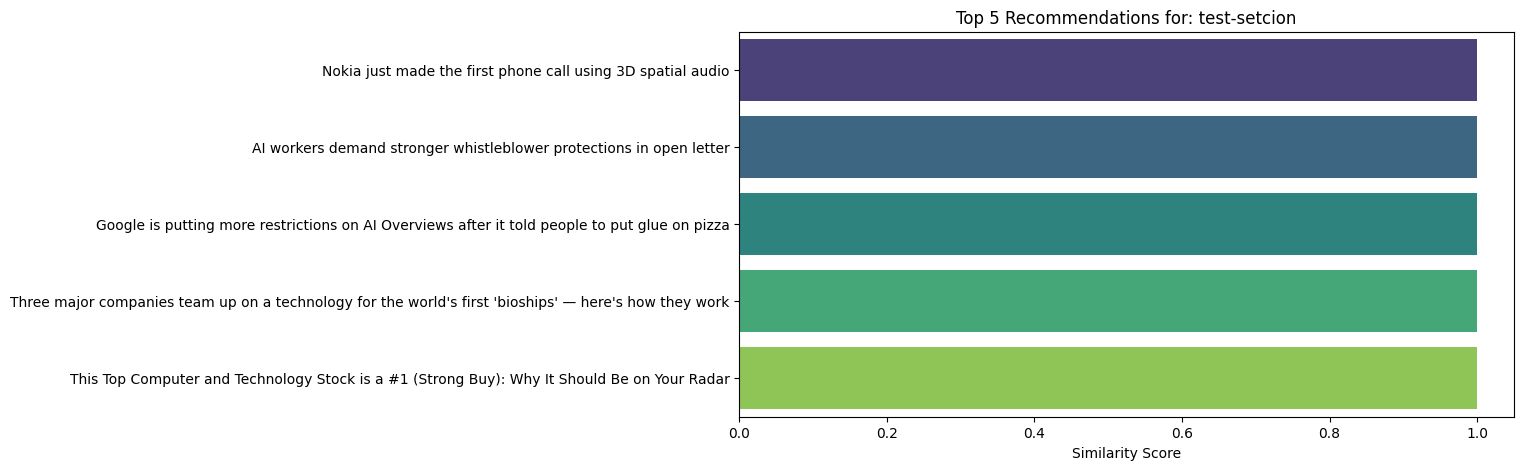

Nokia just made the first phone call using 3D spatial audio — Similarity: 1.00
AI workers demand stronger whistleblower protections in open letter — Similarity: 1.00
Google is putting more restrictions on AI Overviews after it told people to put glue on pizza — Similarity: 1.00
Three major companies team up on a technology for the world's first 'bioships' — here's how they work — Similarity: 1.00
This Top Computer and Technology Stock is a #1 (Strong Buy): Why It Should Be on Your Radar — Similarity: 1.00


In [ ]:
recommend_with_graph(0, top_n=5)

#Interactive Article Recommendation Using Index




List of all article titles:
0: test-setcion
1: Don’t Let Mistrust of Tech Companies Blind You to the Power of AI
2: OpenAI Offers a Peek Inside the Guts of ChatGPT
3: The Rebirth of Queer Cruising Apps
4: [Removed]
5: Internal Emails Show How a Controversial Gun-Detection System Found Its Way to NYC
6: Nokia just made the first phone call using 3D spatial audio
7: OpenAI Unveils GPT-4 Omni’s Voice Capabilities and They’re Literally Unbelievable
8: Windows Is Getting Its Own AI Upscaler That Promises Better Frames in Any Game on Copilot+
9: Alexa Will Get an Upgrade But It'll Cost You, Report Says
10: [Removed]
11: [Removed]
12: Micro LED monitors connect like puzzle pieces in HP multi-monitor concept
13: 12 predictions for the future of technology | Vinod Khosla
14: AI workers demand stronger whistleblower protections in open letter
15: Apple expected to upgrade Siri with AI technology
16: Is This the End of Plastic? Visa’s New Technology Could Render Physical Cards Obsolete - CNET
17:

/tmp/ipython-input-475/4031343370.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sim_scores, y=titles, palette='viridis')


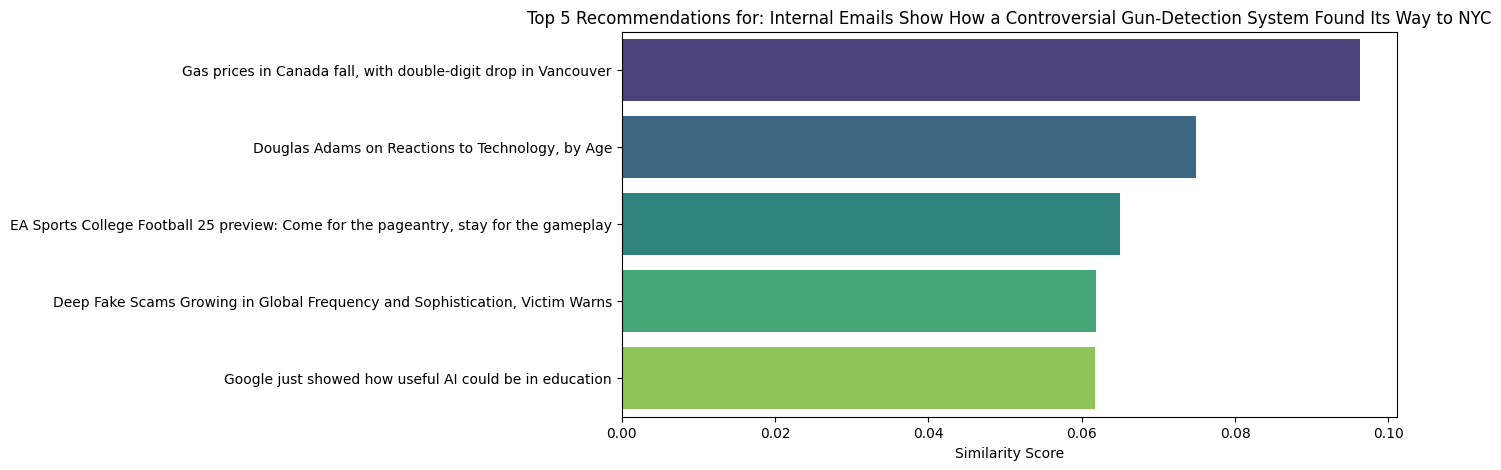

Gas prices in Canada fall, with double-digit drop in Vancouver — Similarity: 0.10
Douglas Adams on Reactions to Technology, by Age — Similarity: 0.07
EA Sports College Football 25 preview: Come for the pageantry, stay for the gameplay — Similarity: 0.06
Deep Fake Scams Growing in Global Frequency and Sophistication, Victim Warns — Similarity: 0.06
Google just showed how useful AI could be in education — Similarity: 0.06

All recommendations saved as 'article_recommendations_full.csv'


In [ ]:
 # Use any article index
 # Change 0 to any article index

# Optional: Interactive Recommendation
print("List of all article titles:")
for i, title in enumerate(df['title']):
    print(f"{i}: {title}")

article_index = int(input("Enter article number to get recommendations: "))
recommend_with_graph(article_index, top_n=5)

# Optional: Save All Recommendations to CSV
all_recommendations = []

for idx in range(len(df)):
    scores = list(enumerate(cosine_sim[idx]))
    scores = sorted(scores, key=lambda x: x[1], reverse=True)[1:6]  # top 5
    for i, score in scores:
        rec = {
            'article_index': idx,
            'article_title': df.loc[idx, 'title'],
            'recommended_index': i,
            'recommended_title': df.loc[i, 'title'],
            'similarity': score
        }
        # Add extra info if exists
        for col in df.columns:
            rec[f'article_{col}'] = df.loc[idx, col]
            rec[f'recommended_{col}'] = df.loc[i, col]
        all_recommendations.append(rec)

recommend_df = pd.DataFrame(all_recommendations)
recommend_df.to_csv('article_recommendations_full.csv', index=False)
print("\nAll recommendations saved as 'article_recommendations_full.csv'")


#Word Cloud of Top Recommendations

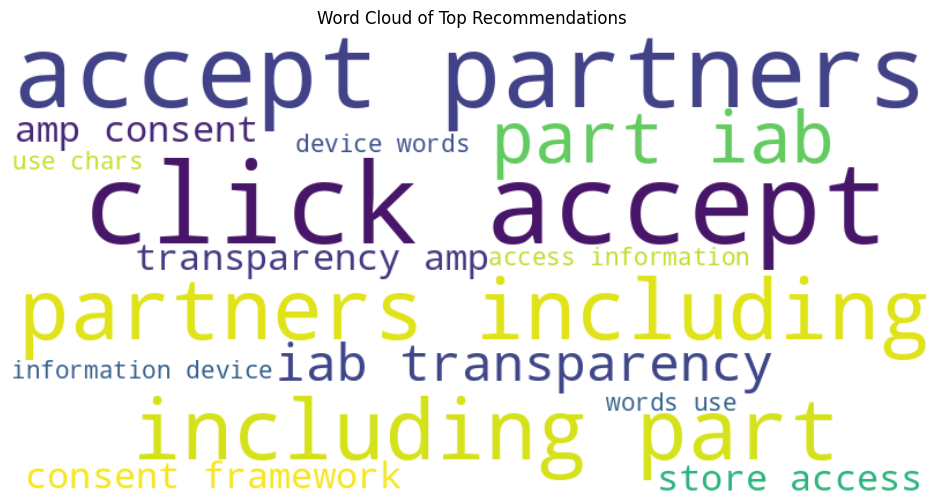

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt # Ensure plt is imported for plotting

# Define article_index and calculate scores for the word cloud
# This assumes you want a word cloud for recommendations related to article 0
# You can change 'article_index' to any valid index.
article_index = 0
scores = list(enumerate(cosine_sim[article_index]))
scores = sorted(scores, key=lambda x: x[1], reverse=True)

# Combine content of top recommendations
top_content = " ".join([df.loc[i, 'content'] for i, _ in scores[1:6]])

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(top_content)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud of Top Recommendations")
plt.show()

In [ ]:
def recommend_by_category(article_index, category=None, top_n=5):
    scores = list(enumerate(cosine_sim[article_index]))
    scores = sorted(scores, key=lambda x: x[1], reverse=True)

    top_articles = []
    for i, score in scores[1:]:
        if category is None or df.loc[i, 'category'] == category:
            top_articles.append((i, score))
        if len(top_articles) == top_n:
            break

    print(f"\nTop {top_n} Recommendations for '{df.loc[article_index,'title']}'" + (f" in category '{category}'" if category else ""))
    for i, score in top_articles:
        row = df.iloc[i]
        print(f"Title: {row['title']} — Category: {row.get('category', 'N/A')} — Similarity: {score:.2f}")


#Article Recommendation Using Dropdown

Dropdown(description='Select Article:', layout=Layout(width='90%'), options=('test-setcion', 'Don’t Let Mistru…

/tmp/ipython-input-475/4031343370.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sim_scores, y=titles, palette='viridis')


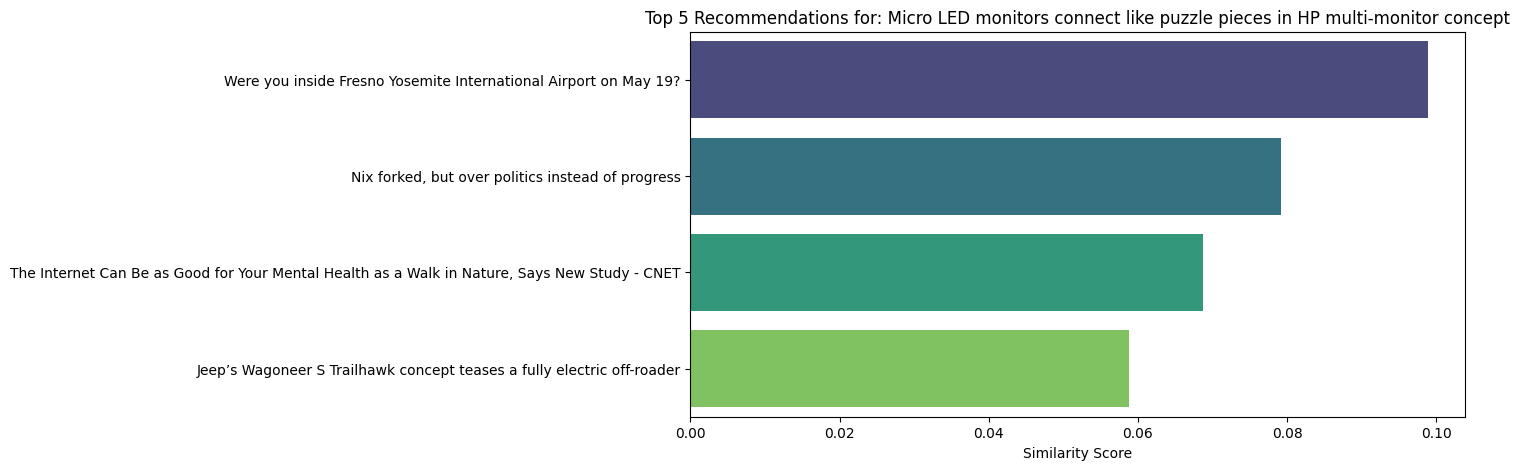

Were you inside Fresno Yosemite International Airport on May 19? — Similarity: 0.10
Nix forked, but over politics instead of progress — Similarity: 0.08
The Internet Can Be as Good for Your Mental Health as a Walk in Nature, Says New Study - CNET — Similarity: 0.07
The Internet Can Be as Good for Your Mental Health as a Walk in Nature, Says New Study - CNET — Similarity: 0.07
Jeep’s Wagoneer S Trailhawk concept teases a fully electric off-roader — Similarity: 0.06


In [ ]:
from ipywidgets import widgets
from IPython.display import display

dropdown = widgets.Dropdown(
    options=df['title'].tolist(),
    description='Select Article:',
    layout=widgets.Layout(width='90%')
)
display(dropdown)

def on_change(change):
    if change['type'] == 'change' and change['name'] == 'value':
        idx = df[df['title'] == change['new']].index[0]
        recommend_with_graph(idx, top_n=5)

dropdown.observe(on_change)


#Histogram of Distribution of Article Similarity Scores

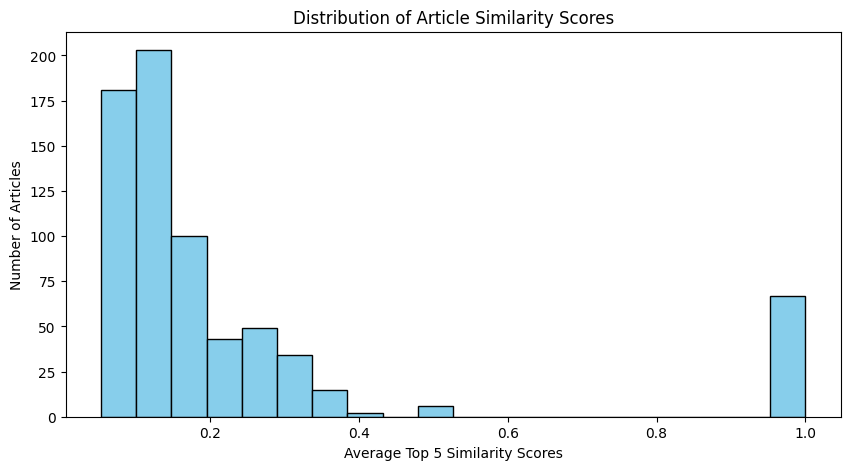

In [ ]:
top_scores = [sorted(cosine_sim[i], reverse=True)[1:6] for i in range(len(df))]
avg_scores = [sum(scores)/len(scores) for scores in top_scores]

plt.figure(figsize=(10,5))
plt.hist(avg_scores, bins=20, color='skyblue', edgecolor='black')
plt.xlabel("Average Top 5 Similarity Scores")
plt.ylabel("Number of Articles")
plt.title("Distribution of Article Similarity Scores")
plt.show()


#Save full recommendation dataset to CSV

In [ ]:
all_recommendations = []

for idx in range(len(df)):
    scores = list(enumerate(cosine_sim[idx]))
    scores = sorted(scores, key=lambda x: x[1], reverse=True)[1:6]  # top 5
    for i, score in scores:
        rec = {
            'article_index': idx,
            'article_title': df.loc[idx, 'title'],
            'recommended_index': i,
            'recommended_title': df.loc[i, 'title'],
            'similarity': score
        }
        # Add all metadata
        for col in df.columns:
            rec[f'article_{col}'] = df.loc[idx, col]
            rec[f'recommended_{col}'] = df.loc[i, col]
        all_recommendations.append(rec)

recommend_df = pd.DataFrame(all_recommendations)
recommend_df.to_csv('article_recommendations_full.csv', index=False)
print("✅ All recommendations saved as 'article_recommendations_full.csv'")


✅ All recommendations saved as 'article_recommendations_full.csv'


#Perfroming K_Means Clustering

TF-IDF matrix shape: (700, 4869)


/tmp/ipython-input-475/3973430922.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cluster_counts.index, y=cluster_counts.values, palette='Set2')


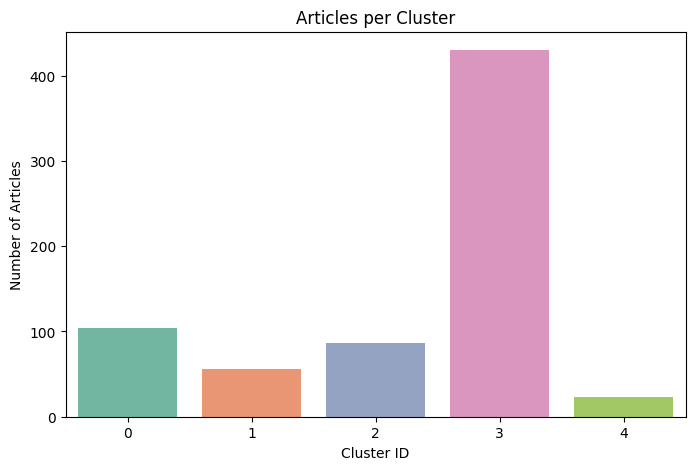

KMeans clustering complete. Added 'cluster' column to dataframe.

                                               title  cluster
0                                       test-setcion        3
1  Don’t Let Mistrust of Tech Companies Blind You...        3
2    OpenAI Offers a Peek Inside the Guts of ChatGPT        3
3                 The Rebirth of Queer Cruising Apps        3
4                                          [Removed]        4


In [ ]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import TfidfVectorizer

# Prepare TF-IDF matrix
tfidf = TfidfVectorizer(stop_words='english', max_features=5000)
tfidf_matrix = tfidf.fit_transform(df['content'])
print("TF-IDF matrix shape:", tfidf_matrix.shape)

# -----------------------------------------------
# KMeans Clustering
# -----------------------------------------------
num_clusters = min(5, len(df))  # safe for small datasets
kmeans = KMeans(n_clusters=num_clusters, random_state=42)
clusters = kmeans.fit_predict(tfidf_matrix)
df['cluster'] = clusters

# Visualize cluster distribution
cluster_counts = df['cluster'].value_counts().sort_index()
plt.figure(figsize=(8,5))
sns.barplot(x=cluster_counts.index, y=cluster_counts.values, palette='Set2')
plt.title("Articles per Cluster")
plt.xlabel("Cluster ID")
plt.ylabel("Number of Articles")
plt.show()

print("KMeans clustering complete. Added 'cluster' column to dataframe.\n")
print(df[['title','cluster']].head())



#LDA Topic Modeling

/tmp/ipython-input-475/54478641.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=topic_counts.index, y=topic_counts.values, palette='Set3')


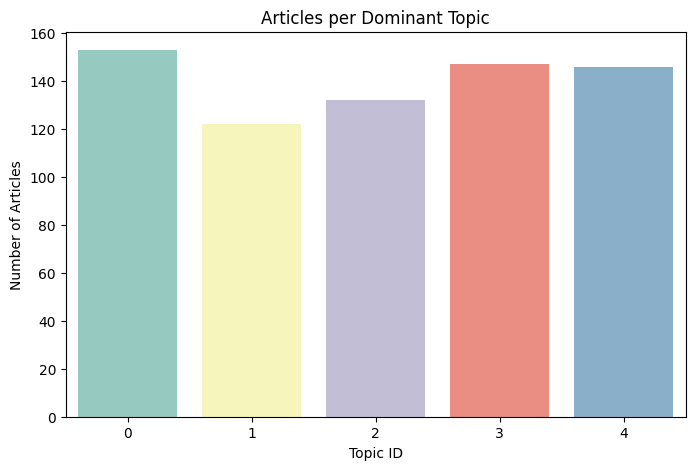

✅ LDA topic modeling complete. Added 'dominant_topic' column to dataframe.

                                               title  dominant_topic
0                                       test-setcion               0
1  Don’t Let Mistrust of Tech Companies Blind You...               3
2    OpenAI Offers a Peek Inside the Guts of ChatGPT               1
3                 The Rebirth of Queer Cruising Apps               1
4                                          [Removed]               4


In [ ]:
num_topics = min(5, tfidf_matrix.shape[1], len(df))  # safe limits
lda = LatentDirichletAllocation(n_components=num_topics, random_state=42)
lda_topics = lda.fit_transform(tfidf_matrix)
df['dominant_topic'] = np.argmax(lda_topics, axis=1)

# Visualize topic distribution
topic_counts = df['dominant_topic'].value_counts().sort_index()
plt.figure(figsize=(8,5))
sns.barplot(x=topic_counts.index, y=topic_counts.values, palette='Set3')
plt.title("Articles per Dominant Topic")
plt.xlabel("Topic ID")
plt.ylabel("Number of Articles")
plt.show()

print("✅ LDA topic modeling complete. Added 'dominant_topic' column to dataframe.\n")
print(df[['title','dominant_topic']].head())

# -----------------------------------------------


#Evaluation Metrics

In [ ]:
import numpy as np

def evaluate_model(similarity_matrix, top_k=5):
    precision_scores = []
    recall_scores = []

    for idx in range(len(df)):
        true_category = df.loc[idx, 'category']

        # Sort by similarity
        scores = list(enumerate(similarity_matrix[idx]))
        scores = sorted(scores, key=lambda x: x[1], reverse=True)[1:top_k+1]

        recommended_indices = [i for i, _ in scores]
        recommended_categories = df.loc[recommended_indices, 'category']

        correct = sum(recommended_categories == true_category)
        precision = correct / top_k

        total_relevant = sum(df['category'] == true_category) - 1
        recall = correct / total_relevant if total_relevant != 0 else 0

        precision_scores.append(precision)
        recall_scores.append(recall)

    avg_precision = np.mean(precision_scores)
    avg_recall = np.mean(recall_scores)
    f1 = (2 * avg_precision * avg_recall) / (avg_precision + avg_recall + 1e-10)
    return avg_precision, avg_recall, f1

#Evaluating Euclidean similarity & (TF-IDF + Cosine) & (TF-IDF + Euclidean)

In [ ]:
from sklearn.metrics.pairwise import euclidean_distances

# Cosine similarity already exists
# Euclidean similarity (convert distance to similarity)
euclidean_dist = euclidean_distances(tfidf_matrix)
euclidean_sim = 1 / (1 + euclidean_dist)

# Evaluate both methods
cos_prec, cos_rec, cos_f1 = evaluate_model(cosine_sim)
euc_prec, euc_rec, euc_f1 = evaluate_model(euclidean_sim)

print("TF-IDF + Cosine")
print("Precision@5:", round(cos_prec,3), "Recall@5:", round(cos_rec,3), "F1 Score:", round(cos_f1,3))

print("\nTF-IDF + Euclidean")
print("Precision@5:", round(euc_prec,3), "Recall@5:", round(euc_rec,3), "F1 Score:", round(euc_f1,3))

TF-IDF + Cosine
Precision@5: 0.362 Recall@5: 0.018 F1 Score: 0.035

TF-IDF + Euclidean
Precision@5: 0.362 Recall@5: 0.018 F1 Score: 0.035


#Proposed Hybrid Model

In [ ]:
# -----------------------------------------------
# Section 3: Hybrid Model (Cosine + Cluster)
# -----------------------------------------------

#  Step 1: Ensure KMeans clustering exists
from sklearn.cluster import KMeans
import numpy as np

# Create KMeans clusters if not already done
if 'cluster' not in df.columns:
    num_clusters = min(5, len(df))  # safe for small datasets
    kmeans = KMeans(n_clusters=num_clusters, random_state=42)
    df['cluster'] = kmeans.fit_predict(tfidf_matrix)
    print(" KMeans clustering done. Added 'cluster' column.")
else:
    print(" 'cluster' column already exists.")

print(df[['title', 'cluster']].head())

#  Step 2: Create cluster similarity matrix
cluster_sim = np.zeros((len(df), len(df)))

for i in range(len(df)):
    for j in range(len(df)):
        if df.loc[i, 'cluster'] == df.loc[j, 'cluster']:
            cluster_sim[i][j] = 1

#  Step 3: Compute hybrid similarity
alpha = 0.6  # weight for cosine similarity
beta = 0.4   # weight for cluster similarity

hybrid_sim = alpha * cosine_sim + beta * cluster_sim

# Step 4: Evaluation (optional: using previous evaluate_model function)
if 'category' in df.columns:
    hyb_prec, hyb_rec, hyb_f1 = evaluate_model(hybrid_sim)
    print("\nHybrid Model (Cosine + Cluster) Evaluation:")
    print(f"Precision@5: {hyb_prec:.3f}")
    print(f"Recall@5: {hyb_rec:.3f}")
    print(f"F1 Score: {hyb_f1:.3f}")
else:
    print(" 'category' column not found. Skipping evaluation.")

#  Step 5: Example recommendation using hybrid similarity
def recommend_hybrid(article_index, top_n=5):
    scores = list(enumerate(hybrid_sim[article_index]))
    scores = sorted(scores, key=lambda x: x[1], reverse=True)[1:top_n+1]

    print(f"\nTop {top_n} recommendations for: {df.loc[article_index,'title']} (Hybrid Model)")
    for i, score in scores:
        print(f"{df.loc[i,'title']} — Similarity: {score:.2f}")

# Test example
recommend_hybrid(0, top_n=5)


 'cluster' column already exists.
                                               title  cluster
0                                       test-setcion        3
1  Don’t Let Mistrust of Tech Companies Blind You...        3
2    OpenAI Offers a Peek Inside the Guts of ChatGPT        3
3                 The Rebirth of Queer Cruising Apps        3
4                                          [Removed]        4

Hybrid Model (Cosine + Cluster) Evaluation:
Precision@5: 0.379
Recall@5: 0.019
F1 Score: 0.036

Top 5 recommendations for: test-setcion (Hybrid Model)
Nokia just made the first phone call using 3D spatial audio — Similarity: 1.00
AI workers demand stronger whistleblower protections in open letter — Similarity: 1.00
Google is putting more restrictions on AI Overviews after it told people to put glue on pizza — Similarity: 1.00
Three major companies team up on a technology for the world's first 'bioships' — here's how they work — Similarity: 1.00
This Top Computer and Technology Stock is 

#Final Result Comparison Table

In [ ]:
results = pd.DataFrame({
    "Method": ["TF-IDF + Cosine", "TF-IDF + Euclidean", "Hybrid (Cosine + Cluster)"],
    "Precision@5": [cos_prec, euc_prec, hyb_prec],
    "Recall@5": [cos_rec, euc_rec, hyb_rec],
    "F1 Score": [cos_f1, euc_f1, hyb_f1]
})

results

,Method,Precision@5,Recall@5,F1 Score
0,TF-IDF + Cosine,0.362286,0.018297,0.034835
1,TF-IDF + Euclidean,0.362286,0.018297,0.034835
2,Hybrid (Cosine + Cluster),0.379143,0.019149,0.036456


#Model Performance Comparison

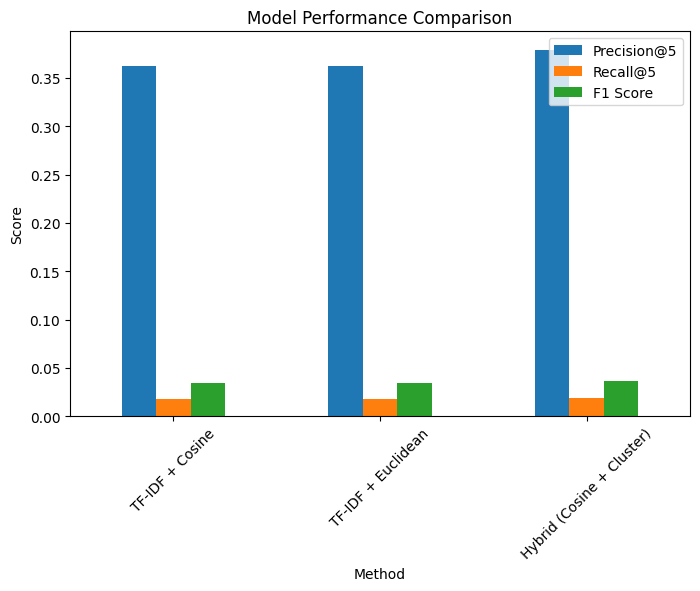

In [ ]:
import matplotlib.pyplot as plt

results.set_index("Method").plot(kind='bar', figsize=(8,5))
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.show()
